# Step 4: Explainability Audit

This notebook asks which features drive the baseline model's decisions and how much of that influence sits on sensitive features, following survey section 4.3.

Measures:

- **SHAP importance** `I_j = mean(|phi_j|)` over the test rows, where `phi_j` is feature j's contribution to a prediction
- **Importance share** `share_j = I_j / sum(I)`
- **Sensitive Feature Influence** = the summed share of `RAC1P`, `SEX` and `POBP` (the set chosen in notebook 01)
- **Counterfactual flip rate** = share of decisions that change when only a protected attribute is changed. This is the model-level version of the single-applicant check the dashboard will offer.

Notes for the write-up:
1. Contributions use XGBoost's exact built-in TreeSHAP, on the log-odds scale. Categorical columns stay single features, so `OCCP` and `POBP` are not split across hundreds of dummy columns.
2. SHAP shows influence. It is not proof of discrimination, so read it next to the fairness result.
3. The thresholds (sensitive share 10%, flip rate 5%) are documented defaults, with a sensitivity check below.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.model import load_processed, to_model_frame
from src.audit.explainability import (
    audit_explainability, shap_values, explain_row, SENSITIVE_FEATURES, DEFAULT_THRESHOLDS,
)

PROCESSED_DIR = os.path.abspath("../data/processed")
RESULTS_DIR = os.path.abspath("../results")

X_train, X_test, y_train, y_test, g_train, g_test = load_processed(PROCESSED_DIR)
Xtr, Xte = to_model_frame(X_train, X_test)

model = XGBClassifier()
model.load_model(os.path.join(RESULTS_DIR, "baseline_xgb.json"))
print("Test rows:", Xte.shape, " Sensitive features:", SENSITIVE_FEATURES)

Test rows: (38642, 10)  Sensitive features: ['RAC1P', 'SEX', 'POBP']


## 1. Sanity check: SHAP values must add up

For every row, the contributions plus the bias term should equal the model's raw (log-odds) output. If this fails, the SHAP numbers cannot be trusted.

In [2]:
shap_df, bias = shap_values(model, Xte)
margin = model.predict(Xte, output_margin=True)
max_gap = np.abs(shap_df.sum(axis=1).to_numpy() + bias - margin).max()
print(f"Largest |sum(SHAP) + bias - model output| over all rows: {max_gap:.2e}")
assert max_gap < 1e-3

Largest |sum(SHAP) + bias - model output| over all rows: 1.14e-05


## 2. Run the explainability audit

The counterfactual check changes `SEX` between its two values, and `RAC1P` between the groups that have at least 30 test rows (group 4 is skipped, as in the fairness audit).

In [3]:
rac_counts = X_test["RAC1P"].astype(int).value_counts()
rac_values = sorted(rac_counts[rac_counts >= 30].index.tolist())
flip_values = {"SEX": [1, 2], "RAC1P": rac_values}

result = audit_explainability(model, Xte, flip_values=flip_values)
print(result.summary())

Explainability: risk 0.795 (fail)
  - Most influential features: OCCP (26.4%), WKHP (18.8%), AGEP (14.1%).
  - Sensitive features ['RAC1P', 'SEX', 'POBP'] carry 12.4% of total SHAP importance (limit 10%). Read with the fairness module: this shows influence, not proof of discrimination.
  - 8.0% of decisions change when only SEX is changed (limit 5%).
  - 7.7% of decisions change when only RAC1P is changed (limit 5%).


In [4]:
imp = result.details["importance"]
imp.assign(sensitive=imp.index.isin(SENSITIVE_FEATURES)).round(4)

,mean_abs_shap,share,rank,sensitive
OCCP,1.0592,0.2645,1,False
WKHP,0.7522,0.1878,2,False
AGEP,0.5633,0.1407,3,False
SCHL,0.5133,0.1282,4,False
RELSHIPP,0.3699,0.0924,5,False
SEX,0.2052,0.0512,6,True
POBP,0.1985,0.0496,7,True
COW,0.1512,0.0378,8,False
MAR,0.0986,0.0246,9,False
RAC1P,0.0935,0.0234,10,True


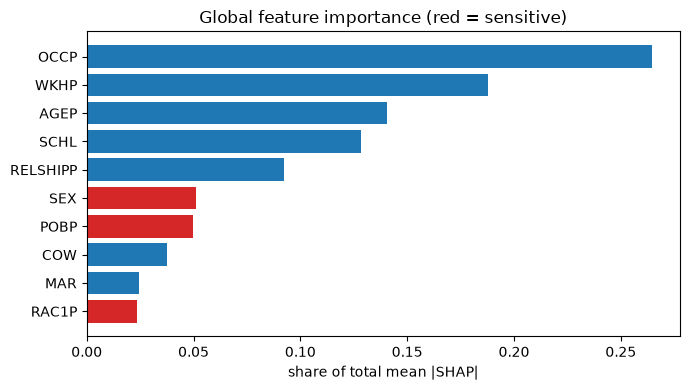

In [5]:
colors = ["tab:red" if f in SENSITIVE_FEATURES else "tab:blue" for f in imp.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index[::-1], imp["share"][::-1], color=colors[::-1])
ax.set_xlabel("share of total mean |SHAP|")
ax.set_title("Global feature importance (red = sensitive)")
plt.tight_layout()
plt.show()

## 3. Counterfactual detail

`any_flip_rate` is the share of test rows whose decision changes under at least one alternative value of the attribute. `per_value` is the flip rate when every row is moved to that one value.

In [6]:
for feat, f in result.metrics["counterfactual"].items():
    print(f"{feat}: any_flip_rate = {f['any_flip_rate']:.4f}")
    print("   per value:", {k: round(v, 4) for k, v in f["per_value"].items()})

SEX: any_flip_rate = 0.0795
   per value: {'1': 0.07, '2': 0.0881}
RAC1P: any_flip_rate = 0.0769
   per value: {'1': 0.0326, '2': 0.0476, '3': 0.0395, '5': 0.0321, '6': 0.0267, '7': 0.0444, '8': 0.0403, '9': 0.0234}


## 4. Direction of the sensitive-feature effect

Importance says how much a feature matters, not which way it pushes. The table below is the average signed SHAP value of `RAC1P` within each race group, and of `SEX` within each sex group. A negative value means that feature, on average, pushes that group's predictions down.

In [7]:
sv = result.details["shap_values"]
Xs = result.details["X"]
for feat in ("RAC1P", "SEX"):
    t = sv[feat].groupby(Xs[feat].astype(int)).agg(["mean", "count"]).rename(columns={"mean": "mean_signed_shap", "count": "n"})
    print(f"\nMean signed SHAP of {feat}, by {feat} group (log-odds):")
    print(t.round(4))


Mean signed SHAP of RAC1P, by RAC1P group (log-odds):
       mean_signed_shap      n
RAC1P                         
1                0.0812  15903
2               -0.2002   1637
3               -0.1512    502
4                0.0969      1
5               -0.0873     84
6                0.0158   7189
7               -0.1343    139
8               -0.1485   6706
9               -0.0236   6481

Mean signed SHAP of SEX, by SEX group (log-odds):
     mean_signed_shap      n
SEX                         
1              0.1918  20370
2             -0.2048  18272


## 5. One applicant (preview of the dashboard)

The same SHAP values explain a single decision. This is the function the dashboard will call for the applicant form.

In [8]:
idx = Xs.index[0]
proba = model.predict_proba(Xs.loc[[idx]])[0, 1]
print(f"Row {idx}: predicted probability of eligible = {proba:.3f}")
explain_row(sv, Xs, idx, top=6).round(3)

Row 0: predicted probability of eligible = 0.089


,value,contribution
WKHP,30.0,-1.496
RELSHIPP,25.0,-0.809
SCHL,21.0,0.347
OCCP,5940.0,-0.268
AGEP,37.0,0.207
SEX,2.0,-0.147


## 6. Sensitivity to the thresholds

Reruns the audit with both thresholds scaled by 0.5, 1 and 1.5.

In [9]:
rows = []
for scale in (0.5, 1.0, 1.5):
    thr = {k: v * scale for k, v in DEFAULT_THRESHOLDS.items()}
    r = audit_explainability(model, Xte, flip_values=flip_values, thresholds=thr)
    rows.append({"threshold_scale": scale, **{k: round(v, 3) for k, v in r.metrics["risks"].items()},
                 "overall_risk": round(r.risk, 3), "status": r.status})
pd.DataFrame(rows)

,threshold_scale,sensitive_share,flip_SEX,flip_RAC1P,overall_risk,status
0,0.5,1.000,1.000,1.000,1.000,fail
1,1.0,0.621,0.795,0.769,0.795,fail
2,1.5,0.414,0.530,0.513,0.530,warn


## 7. Save the result

In [10]:
out = {
    "name": result.name, "risk": result.risk, "status": result.status,
    "findings": result.findings, "metrics": result.metrics,
    "importance": imp.reset_index().rename(columns={"index": "feature"}).to_dict(orient="records"),
}
path = os.path.join(RESULTS_DIR, "explainability_result.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Saved", path)

Saved E:\MTECH\Final_yr_project\results\explainability_result.json


## Summary and next step

- Verified the SHAP values add up to the model output, then ranked features by mean |SHAP|.
- Measured the share of influence on sensitive features and the counterfactual flip rate for `SEX` and `RAC1P`.
- Saved a `ModuleResult` to `results/explainability_result.json`.

**Next:** notebook 05, the Reliability audit (Brier Score and Expected Calibration Error on the saved probabilities).